## Step 1 --- Install & Import

In [7]:
# Run once — installs all required libraries
import subprocess
subprocess.run(['pip', 'install', 'transformers', 'torch', 'numpy', 'matplotlib',
                'seaborn', 'scikit-learn', 'nltk', 'lime', 'pandas'], check=True)

CompletedProcess(args=['pip', 'install', 'transformers', 'torch', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'nltk', 'lime', 'pandas'], returncode=0)

In [8]:
import re, random, string, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import torch
import torch.nn as nn
import pandas as pd

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, f1_score, precision_score, recall_score)
from lime.lime_text import LimeTextExplainer
from transformers import BertTokenizer, BertModel

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# ── Global settings ──────────────────────────────────────────────
MAX_LEN       = 256      # BERT max sequence length (can go up to 512)
BATCH_SIZE    = 32       # Smaller batch for BERT memory requirements
EPOCHS        = 3        # BERT converges faster, 3 epochs usually enough
BERT_MODEL    = 'bert-base-uncased'
STOP_WORDS    = set(stopwords.words('english'))

# Transformer hyperparameters (tunable for best performance)
D_MODEL  = 768           # BERT hidden size (must match BERT output: 768)
N_HEADS  = 8             # Number of attention heads (768/8 = 96 per head)
N_LAYERS = 3             # More layers for better representation
D_FF     = 1024          # Feed-forward dimension
DROPOUT  = 0.2           # Slightly lower dropout for BERT
LR       = 2e-5          # Lower learning rate for fine-tuning BERT

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print('All imports successful ✓')

Device: cuda
All imports successful ✓


## Step 2 --- Load & Clean IMDb Data

IMDb comes as integer sequences. We decode them back to text, then clean with NLTK:

- Lowercase everything
- Strip HTML tags
- Remove punctuation and digits
- Drop stopwords ("the", "is", "a"...)
- Keep only words longer than 2 characters

In [9]:
# Load raw integer-encoded reviews (use full vocabulary for BERT)
(x_tr_enc, y_train), (x_te_enc, y_test) = imdb.load_data(num_words=None)
y_train, y_test = np.array(y_train), np.array(y_test)

# Decode integers → readable text (correct v+3 offset)
word_index = imdb.get_word_index()
idx2word   = {v + 3: k for k, v in word_index.items()}
idx2word.update({0: '<PAD>', 1: '<START>', 2: '<UNK>', 3: '<UNUSED>'})

def decode_review(seq):
    return ' '.join(idx2word.get(i, '<UNK>') for i in seq)

# NLTK cleaning pipeline
def clean_text(text):
    text   = text.lower()
    text   = re.sub(r'<[^>]+>', ' ', text)   # remove HTML
    text   = re.sub(r'[^a-z\s]', ' ', text)  # keep letters only
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    return ' '.join(tokens)

print('Decoding...')
X_train_raw   = [decode_review(s) for s in x_tr_enc]
X_test_raw    = [decode_review(s) for s in x_te_enc]

print('Cleaning with NLTK...')
X_train_clean = [clean_text(r) for r in X_train_raw]
X_test_clean  = [clean_text(r) for r in X_test_raw]

print(f'Train: {len(X_train_clean)}  Test: {len(X_test_clean)}')
print(f'\nSample raw   : {X_train_raw[0][:80]}')
print(f'Sample clean : {X_train_clean[0][:80]}')
print(f'Label        : {"Positive" if y_train[0]==1 else "Negative"}')

Decoding...
Cleaning with NLTK...
Train: 25000  Test: 25000

Sample raw   : <START> this film was just brilliant casting location scenery story direction ev
Sample clean : film brilliant casting location scenery story direction everyone really suited p
Label        : Positive


## Step 3 --- BERT Tokenization

BERT uses WordPiece tokenization which handles subwords (e.g., "playing" → ["play", "##ing"]).
This is more powerful than simple word-level tokenization and handles OOV words better.

In [10]:
print('Loading BERT tokenizer...')
tokenizer = BertTokenizer.from_pretrained(BERT_MODEL)

def encode_texts(texts, max_len=MAX_LEN):
    """Encode texts using BERT tokenizer."""
    encoded = tokenizer(
        texts,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    return encoded['input_ids'], encoded['attention_mask']

print('Tokenizing train set...')
X_train_ids, X_train_mask = encode_texts(X_train_clean)

print('Tokenizing test set...')
X_test_ids, X_test_mask = encode_texts(X_test_clean)

print(f'X_train shape : {X_train_ids.shape}')
print(f'X_test  shape : {X_test_ids.shape}')

# Show sample tokens
sample_tokens = tokenizer.convert_ids_to_tokens(X_train_ids[0][:20])
sample_tokens = [t for t in sample_tokens if t not in ['[PAD]', '[CLS]', '[SEP]']][:7]
print(f'Sample tokens: {sample_tokens}')

Loading BERT tokenizer...
Tokenizing train set...
Tokenizing test set...
X_train shape : torch.Size([25000, 256])
X_test  shape : torch.Size([25000, 256])
Sample tokens: ['film', 'brilliant', 'casting', 'location', 'scenery', 'story', 'direction']


## Step 4 --- BERT + Transformer Model Architecture

We use BERT-base-uncased as the embedding layer, then feed its output to a Transformer encoder.

**Architecture:**
1. BERT embeddings (768-dim) → fine-tuned during training
2. Linear projection (if needed)
3. Transformer Encoder with multi-head self-attention
4. Global average pooling
5. Dropout + Classification head

In [11]:
class BERTTransformerClassifier(nn.Module):
    def __init__(self, bert_model_name, d_model, n_heads, n_layers, d_ff, dropout):
        super().__init__()

        # Load pre-trained BERT
        self.bert = BertModel.from_pretrained(bert_model_name)

        # BERT output dim is 768 for base model
        bert_hidden_size = self.bert.config.hidden_size

        # Project BERT output to d_model if different
        self.projection = nn.Linear(bert_hidden_size, d_model) if bert_hidden_size != d_model else nn.Identity()

        # PyTorch Transformer Encoder
        self.transformer_encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=n_heads,
                dim_feedforward=d_ff,
                dropout=dropout,
                batch_first=True
            ),
            num_layers=n_layers
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, input_ids, attention_mask):
        # Get BERT embeddings (batch_size, seq_len, 768)
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        x = bert_output.last_hidden_state  # (B, seq_len, 768)

        # Project if needed
        x = self.projection(x)  # (B, seq_len, d_model)

        # Apply transformer encoder
        x = self.transformer_encoder(x)  # (B, seq_len, d_model)

        # Global average pooling (mask-aware)
        mask_expanded = attention_mask.unsqueeze(-1).float()
        x = (x * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1).clamp(min=1)

        # Classification
        x = self.dropout(x)
        return torch.sigmoid(self.fc(x)).squeeze(-1)  # (B,)

print('Loading pre-trained BERT...')
model = BERTTransformerClassifier(
    bert_model_name=BERT_MODEL,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT
).to(device)

print(model)
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Loading pre-trained BERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERTTransformerClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, ele

## Step 5 --- Training

We use:
- **AdamW optimizer** with weight decay (better for transformers)
- **Learning rate**: 2e-5 (standard for fine-tuning BERT)
- **Validation split**: 10% of training data
- **Early stopping** based on validation accuracy

In [12]:
import torch
import torch.nn as nn
from tqdm import tqdm

# ── Reproducibility ───────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# ── Data preparation ──────────────────────────────────────────────
y_tr = torch.FloatTensor(y_train).to(device)
y_te = torch.FloatTensor(y_test).to(device)

val_size = int(0.1 * len(X_train_ids))
train_ids,  val_ids  = X_train_ids[val_size:],  X_train_ids[:val_size]
train_mask, val_mask = X_train_mask[val_size:], X_train_mask[:val_size]
train_y,    val_y    = y_tr[val_size:],         y_tr[:val_size]

train_ds = torch.utils.data.TensorDataset(train_ids, train_mask, train_y)
train_dl = torch.utils.data.DataLoader(
    train_ds, batch_size=BATCH_SIZE,
    shuffle=True,                        # already shuffles each epoch
    generator=torch.Generator().manual_seed(SEED)  # deterministic shuffle
)

val_ds = torch.utils.data.TensorDataset(val_ids, val_mask, val_y)
val_dl = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE)

# ── Label-smoothing BCE loss ──────────────────────────────────────
# Prevents the model becoming over-confident (pushes targets away from 0/1)
class LabelSmoothingBCE(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing         # 0.1 → targets become 0.05 / 0.95

    def forward(self, pred, target):
        target_smooth = target * (1 - self.smoothing) + 0.5 * self.smoothing
        return nn.functional.binary_cross_entropy(pred, target_smooth)

loss_fn = LabelSmoothingBCE(smoothing=0.1)

# ── Layer-wise learning rate decay ───────────────────────────────
# BERT backbone: very small LR  (don't destroy pre-trained weights)
# Transformer head + classifier: larger LR  (newly initialised)
bert_params = list(model.bert.parameters())
head_params = list(model.transformer_encoder.parameters()) + \
              list(model.projection.parameters()) + \
              list(model.fc.parameters())

optimizer = torch.optim.AdamW([
    {'params': bert_params, 'lr': LR,       'weight_decay': 0.01},   # 2e-5
    {'params': head_params, 'lr': LR * 10,  'weight_decay': 0.05},   # 2e-4
])

# ── Warmup + cosine-decay scheduler ──────────────────────────────
# First 10% of steps: linear ramp-up  → avoids large gradient updates early on
total_steps  = len(train_dl) * EPOCHS
warmup_steps = int(0.10 * total_steps)

def lr_lambda(current_step):
    if current_step < warmup_steps:
        return current_step / max(1, warmup_steps)           # linear warmup
    progress = (current_step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(0.0, 0.5 * (1.0 + np.cos(np.pi * progress))) # cosine decay

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
global_step = 0

# ── Early stopping ────────────────────────────────────────────────
PATIENCE   = 2          # stop after 2 epochs with no val improvement
best_val   = 0
patience_counter = 0
history    = {'accuracy': [], 'val_accuracy': [], 'loss': []}

# ── Evaluation helper ─────────────────────────────────────────────
def eval_loader_accuracy(model, data_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, mask, yb in tqdm(data_loader, desc='  Evaluating', leave=False):
            xb, mask, yb = xb.to(device), mask.to(device), yb.to(device)
            preds = (model(xb, mask) > 0.5).float()
            correct += (preds == yb).sum().item()
            total   += yb.size(0)
    return correct / total

# ── Training loop ─────────────────────────────────────────────────
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    train_pbar = tqdm(train_dl, desc=f'Epoch {epoch+1}/{EPOCHS}', unit='batch')
    for xb, mask, yb in train_pbar:
        xb, mask, yb = xb.to(device), mask.to(device), yb.to(device)

        optimizer.zero_grad()
        pred = model(xb, mask)
        loss = loss_fn(pred, yb)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()          # step every batch (LambdaLR)
        global_step += 1

        total_loss += loss.item()
        train_pbar.set_postfix(loss=f'{loss.item():.4f}')

    tr_acc   = eval_loader_accuracy(model, train_dl)
    va_acc   = eval_loader_accuracy(model, val_dl)
    avg_loss = total_loss / len(train_dl)

    history['accuracy'].append(tr_acc)
    history['val_accuracy'].append(va_acc)
    history['loss'].append(avg_loss)

    print(f'  train_acc={tr_acc:.4f} | val_acc={va_acc:.4f} | avg_loss={avg_loss:.4f}')

    # Save best checkpoint
    if va_acc > best_val:
        best_val = va_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_bert_transformer.pt')
        print('  ✓ Best model saved!')
    else:
        patience_counter += 1
        print(f'  No improvement ({patience_counter}/{PATIENCE})')
        if patience_counter >= PATIENCE:
            print(f'\n  Early stopping triggered after epoch {epoch+1}.')
            break

print('\nTraining complete ✓')

Epoch 1/3: 100%|██████████| 704/704 [21:05<00:00,  1.80s/batch, loss=0.7733]


  train_acc=0.9253 | val_acc=0.8932 | avg_loss=0.4420
  ✓ Best model saved!


Epoch 2/3: 100%|██████████| 704/704 [21:06<00:00,  1.80s/batch, loss=0.2213]


  train_acc=0.9671 | val_acc=0.9092 | avg_loss=0.3299
  ✓ Best model saved!


Epoch 3/3: 100%|██████████| 704/704 [21:06<00:00,  1.80s/batch, loss=0.1996]


  train_acc=0.9771 | val_acc=0.9108 | avg_loss=0.2692
  ✓ Best model saved!

Training complete ✓


## Step 6 --- Evaluate: Accuracy, F1, AUC, Confusion Matrix, ROC Curve

  BERT + Transformer — Test Results
  Accuracy  : 0.9110
  F1-Score  : 0.9115
  AUC-ROC   : 0.9704

              precision    recall  f1-score   support

    Negative       0.92      0.91      0.91     12500
    Positive       0.91      0.92      0.91     12500

    accuracy                           0.91     25000
   macro avg       0.91      0.91      0.91     25000
weighted avg       0.91      0.91      0.91     25000



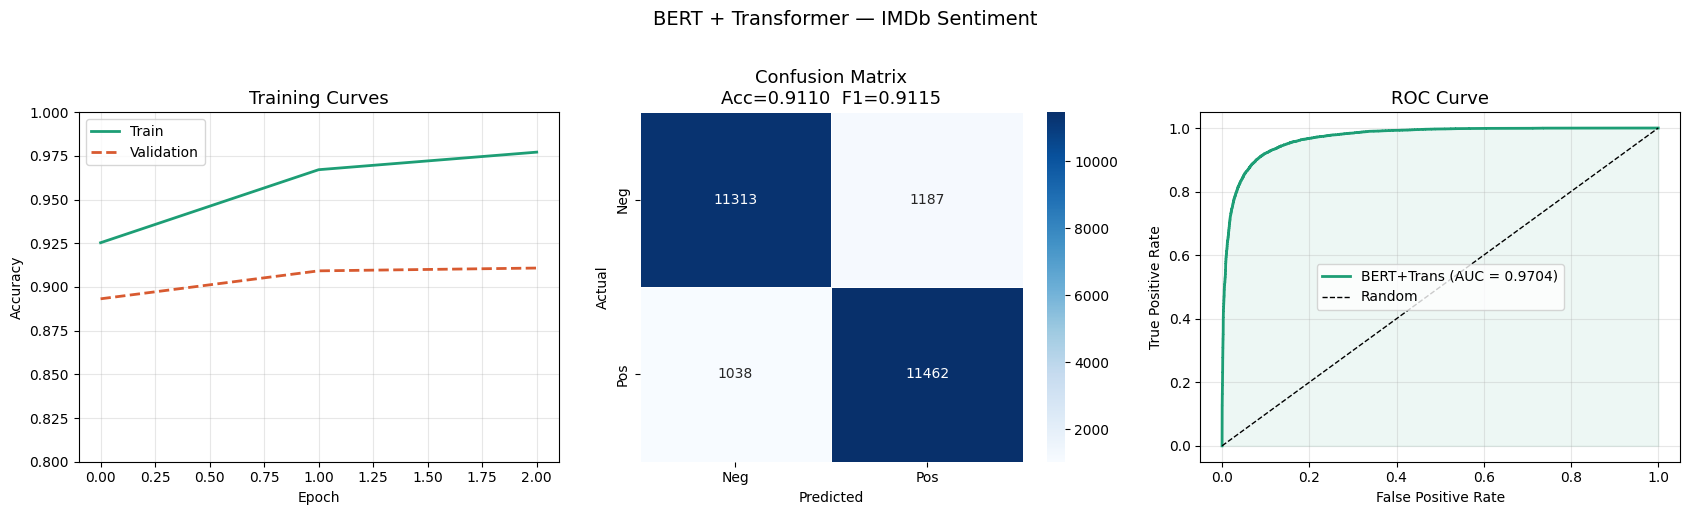

In [13]:
# Load best model
model.load_state_dict(torch.load('best_bert_transformer.pt'))
model.eval()

# Prediction function
def predict_probs(model, input_ids, attention_mask, batch_size=32):
    model.eval()
    probs = []
    with torch.no_grad():
        for i in range(0, len(input_ids), batch_size):
            xb = input_ids[i:i+batch_size].to(device)
            mask = attention_mask[i:i+batch_size].to(device)
            out = model(xb, mask).cpu().numpy()
            probs.append(out)
    return np.concatenate(probs)

y_prob = predict_probs(model, X_test_ids, X_test_mask)
y_pred = (y_prob > 0.5).astype(int)
acc = (y_pred == y_test).mean()

f1     = f1_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc     = auc(fpr, tpr)

print('=' * 44)
print('  BERT + Transformer — Test Results')
print('=' * 44)
print(f'  Accuracy  : {acc:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  AUC-ROC   : {roc_auc:.4f}')
print('=' * 44)
print()
print(classification_report(y_test, y_pred,
                             target_names=['Negative', 'Positive']))


fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Training curves
ax = axes[0]
ax.plot(history['accuracy'],     color='#1D9E75',
        linewidth=2, label='Train')
ax.plot(history['val_accuracy'], color='#D85A30',
        linewidth=2, linestyle='--', label='Validation')
ax.set_title('Training Curves', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.8, 1.0)
ax.legend()
ax.grid(alpha=0.3)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Neg', 'Pos'],
            yticklabels=['Neg', 'Pos'],
            linewidths=0.5)
axes[1].set_title(f'Confusion Matrix\nAcc={acc:.4f}  F1={f1:.4f}',
                   fontsize=13)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# ROC curve
axes[2].plot(fpr, tpr, color='#1D9E75', linewidth=2,
             label=f'BERT+Trans (AUC = {roc_auc:.4f})')
axes[2].plot([0,1],[0,1], 'k--', linewidth=1, label='Random')
axes[2].fill_between(fpr, tpr, alpha=0.08, color='#1D9E75')
axes[2].set_title('ROC Curve', fontsize=13)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('BERT + Transformer — IMDb Sentiment',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Step 7 --- Noise Robustness Study

We inject three types of synthetic noise at increasing intensities and measure accuracy drop:

| Noise type | What it does | Why it matters |
|------------|--------------|----------------|
| Char noise | Swap / delete / insert characters in words | Simulates typos |
| Word dropout | Randomly remove entire words | Simulates missing text |
| OOV injection | Replace words with fake strings not in vocabulary | Tests unknown word handling |

In [14]:
random.seed(42)

def char_noise(text, rate=0.1):
    """Swap / delete / insert a character in `rate` fraction of words."""
    words, out = text.split(), []
    for w in words:
        if len(w) > 2 and random.random() < rate:
            op = random.choice(['swap', 'delete', 'insert'])
            i  = random.randint(0, len(w) - 2)
            if op == 'swap':
                l = list(w); l[i], l[i+1] = l[i+1], l[i]; w = ''.join(l)
            elif op == 'delete':
                w = w[:i] + w[i+1:]
            else:
                w = w[:i] + random.choice(string.ascii_lowercase) + w[i:]
        out.append(w)
    return ' '.join(out)

def word_dropout(text, rate=0.1):
    """Randomly remove `rate` fraction of words."""
    words = text.split()
    kept  = [w for w in words if random.random() > rate]
    return ' '.join(kept) if kept else words[0]

def oov_inject(text, rate=0.1):
    """Replace `rate` fraction of words with fake OOV tokens."""
    return ' '.join(
        'zxq' + str(random.randint(100,999))
        if random.random() < rate else w
        for w in text.split()
    )

def encode_noisy(texts, noise_fn, rate):
    """Apply noise, re-tokenize with BERT."""
    noisy = [noise_fn(t, rate) for t in texts]
    ids, mask = encode_texts(noisy)
    return ids, mask

# Quick demo
s = X_test_clean[0][:60]
print('Original     :', s)
print('Char  20%    :', char_noise(s, 0.2))
print('Dropout 20%  :', word_dropout(s, 0.2))
print('OOV   20%    :', oov_inject(s, 0.2))

Original     : please give one miss kristy swanson rest cast rendered terri
Char  20%    : please ive one miss kristy swanson est acst rendered terir
Dropout 20%  : please give one kristy swanson rest rendered terri
OOV   20%    : zxq199 give one miss zxq570 swanson rest cast rendered terri


In [15]:
ax.set_title('Noise Robustness — BERT + Transformer\n'
             'Accuracy vs Noise Level (Signal-to-Noise Ratio curve)',
             fontsize=13)

Text(0.5, 1.0, 'Noise Robustness — BERT + Transformer\nAccuracy vs Noise Level (Signal-to-Noise Ratio curve)')

Running Char noise...
  0% → 0.9115
  5% → 0.9051
  10% → 0.8970
  20% → 0.8815
  30% → 0.8600
  40% → 0.8374
  50% → 0.8133
Running Word dropout...
  0% → 0.9115
  5% → 0.9065
  10% → 0.9034
  20% → 0.8936
  30% → 0.8806
  40% → 0.8649
  50% → 0.8465
Running OOV injection...
  0% → 0.9115
  5% → 0.9057
  10% → 0.8977
  20% → 0.8684
  30% → 0.8293
  40% → 0.7759
  50% → 0.7241


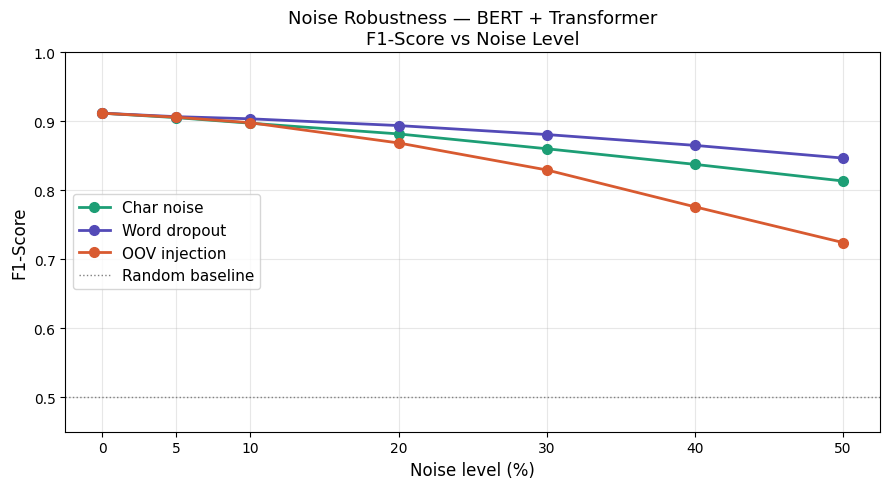


Noise type           Clean    @10%    @30%   Drop@50%
--------------------------------------------------
Char noise          0.9115  0.8970  0.8600    +0.0982
Word dropout        0.9115  0.9034  0.8806    +0.0650
OOV injection       0.9115  0.8977  0.8293    +0.1874


In [16]:
noise_levels  = [0.0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50]
noise_configs = [
    ('Char noise',    char_noise,    '#1D9E75'),
    ('Word dropout',  word_dropout,  '#534AB7'),
    ('OOV injection', oov_inject,    '#D85A30'),
]

snr_results = {}

for label, fn, _ in noise_configs:
    f1s = []
    print(f'Running {label}...')
    for lvl in noise_levels:
        # encode_noisy returns (input_ids, attention_mask)
        ids_noisy, mask_noisy = encode_noisy(X_test_clean, fn, lvl)
        # Unpack them into the predict_probs function
        y_prob_noisy = predict_probs(model, ids_noisy, mask_noisy)
        y_pred_noisy = (y_prob_noisy > 0.5).astype(int).flatten()
        score = f1_score(y_test, y_pred_noisy)
        f1s.append(round(score, 4))
        print(f'  {lvl:.0%} → {score:.4f}')
    snr_results[label] = f1s

# ── Plot SNR curves ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
pct = [x * 100 for x in noise_levels]

fig, ax = plt.subplots(figsize=(9, 5))
for (label, _, color) in noise_configs:
    ax.plot(pct, snr_results[label], '-o', color=color,
            linewidth=2, markersize=7, label=label)

ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='Random baseline')
ax.set_xlabel('Noise level (%)', fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Noise Robustness — BERT + Transformer\nF1-Score vs Noise Level', fontsize=13)
ax.set_ylim(0.45, 1.00)
ax.set_xticks(pct)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Degradation table ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print(f'\n{"Noise type":<18} {"Clean":>7} {"@10%":>7} {"@30%":>7} {"Drop@50%":>10}')
print('-' * 50)
for label, _, _ in noise_configs:
    vals = snr_results[label]
    print(f'{label:<18} {vals[0]:>7.4f} {vals[2]:>7.4f} '
          f'{vals[4]:>7.4f} {vals[0]-vals[-1]:>+10.4f}')

## Step 8 --- Interpretability

### 8A. LIME --- Local Explanation

LIME asks: *"which words in this specific review pushed the model toward Positive or Negative?"* It creates hundreds of modified versions (words removed), runs them through the model, and fits a simple linear model to find which words mattered most.

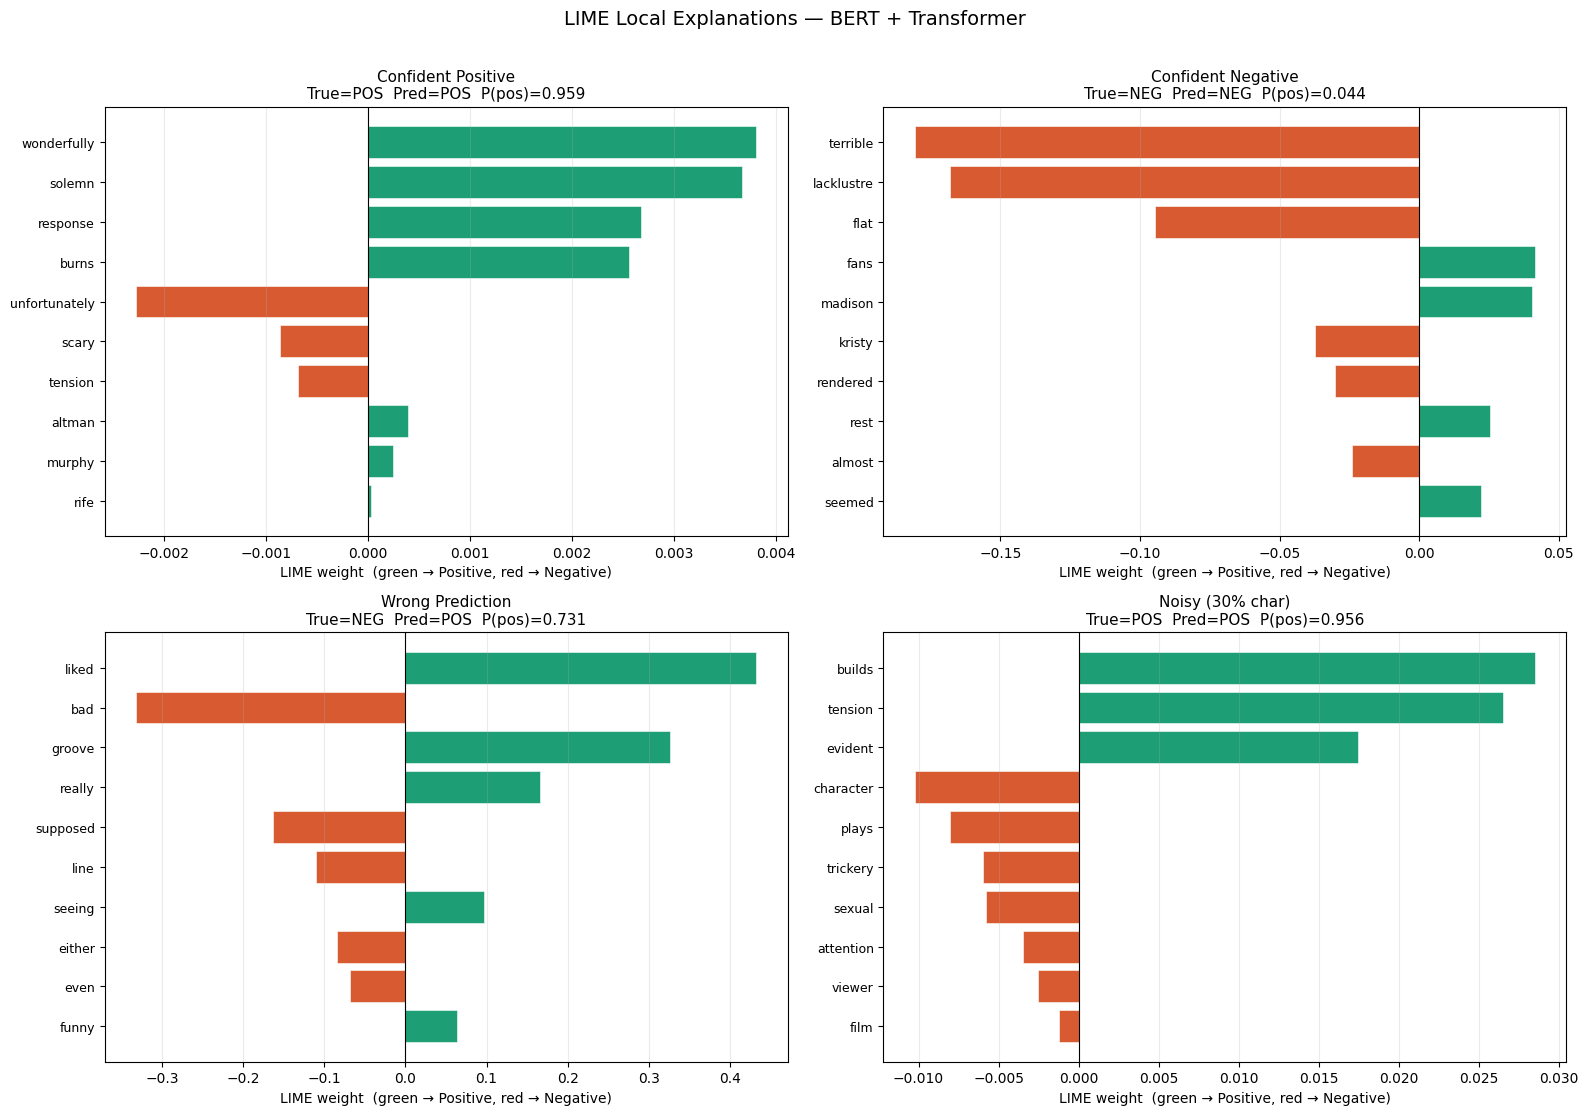

In [17]:
def pipeline_predict(texts):
    """LIME needs a function: list of raw strings → 2-column probabilities."""
    # Clean texts first
    cleaned = [clean_text(t) for t in texts]
    ids, mask = encode_texts(cleaned)
    probs = predict_probs(model, ids, mask).flatten()
    return np.column_stack([1 - probs, probs])  # [P(neg), P(pos)]

explainer = LimeTextExplainer(class_names=['Negative', 'Positive'])

# Pick 4 examples: confident positive, confident negative,
#                  one wrong prediction, one noisy version
idx_pos   = np.where((y_test == 1) & (y_prob > 0.92))[0][0]
idx_neg   = np.where((y_test == 0) & (y_prob < 0.08))[0][0]
idx_wrong = np.where(y_pred != y_test)[0][0]
noisy_txt = char_noise(X_test_clean[idx_pos], 0.30)

samples = [
    ('Confident Positive',   X_test_clean[idx_pos],   y_test[idx_pos]),
    ('Confident Negative',   X_test_clean[idx_neg],   y_test[idx_neg]),
    ('Wrong Prediction',     X_test_clean[idx_wrong],  y_test[idx_wrong]),
    ('Noisy (30% char)',      noisy_txt,                y_test[idx_pos]),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax, (title, text, true_lbl) in zip(axes, samples):
    p   = pipeline_predict([text])[0][1]
    exp = explainer.explain_instance(text, pipeline_predict,
                                      num_features=10, num_samples=400)
    pairs = sorted(exp.as_list(), key=lambda x: abs(x[1]), reverse=True)[:10]
    words_, weights_ = zip(*pairs)

    colors_ = ['#1D9E75' if s > 0 else '#D85A30' for s in weights_]
    ax.barh(range(len(words_)), weights_, color=colors_,
            edgecolor='white', linewidth=0.4)
    ax.set_yticks(range(len(words_)))
    ax.set_yticklabels(words_, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('LIME weight  (green → Positive, red → Negative)')
    ax.set_title(
        f'{title}\n'
        f'True={"POS" if true_lbl==1 else "NEG"}  '
        f'Pred={"POS" if p>0.5 else "NEG"}  P(pos)={p:.3f}',
        fontsize=11)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.25)

plt.suptitle('LIME Local Explanations — BERT + Transformer',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 8B. Attention Visualization

BERT's attention weights show which words the model focuses on when making predictions. We visualize the attention from the [CLS] token to understand what drives the classification decision.

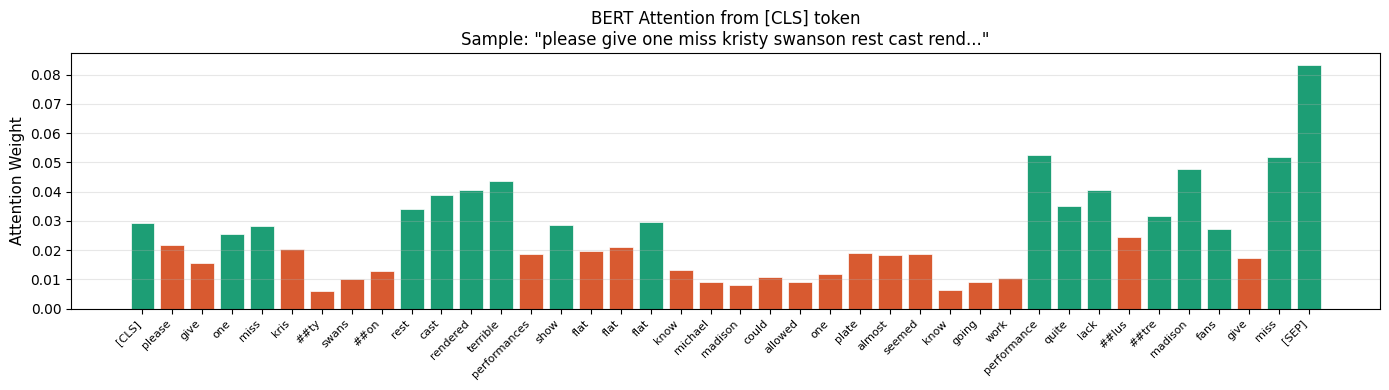

Prediction: Negative (confidence: 0.044)


In [18]:
def get_attention_weights(model, input_ids, attention_mask):
    """Extract attention weights from BERT."""
    model.eval()
    with torch.no_grad():
        outputs = model.bert(input_ids=input_ids, attention_mask=attention_mask, output_attentions=True)
        # outputs.attentions is a tuple of (batch, heads, seq, seq) for each layer
        return outputs.attentions

# Pick a sample review
sample_idx = 0
sample_text = X_test_clean[sample_idx]
sample_ids = X_test_ids[sample_idx:sample_idx+1].to(device)
sample_mask = X_test_mask[sample_idx:sample_idx+1].to(device)

# Fix: switch to eager attention to enable output_attentions
model.bert.config._attn_implementation = "eager"
for layer in model.bert.encoder.layer:
    layer.attention.self.config._attn_implementation = "eager"

# Get attention weights
attentions = get_attention_weights(model, sample_ids, sample_mask)

# Get tokens
tokens = tokenizer.convert_ids_to_tokens(sample_ids[0])
tokens = [t for t in tokens if t != '[PAD]']

# Average attention across all heads in the last layer, from [CLS] token
last_layer_attn = attentions[-1][0].mean(dim=0)  # (seq, seq)
cls_attention = last_layer_attn[0, :len(tokens)].cpu().numpy()

# Plot attention weights
fig, ax = plt.subplots(figsize=(14, 4))
colors = ['#1D9E75' if w > cls_attention.mean() else '#D85A30' for w in cls_attention]
ax.bar(range(len(tokens)), cls_attention, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Attention Weight', fontsize=11)
ax.set_title(f'BERT Attention from [CLS] token\nSample: "{sample_text[:50]}..."', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Prediction: {"Positive" if y_pred[sample_idx]==1 else "Negative"} (confidence: {y_prob[sample_idx]:.3f})')

Words encoded with BERT: 45/45


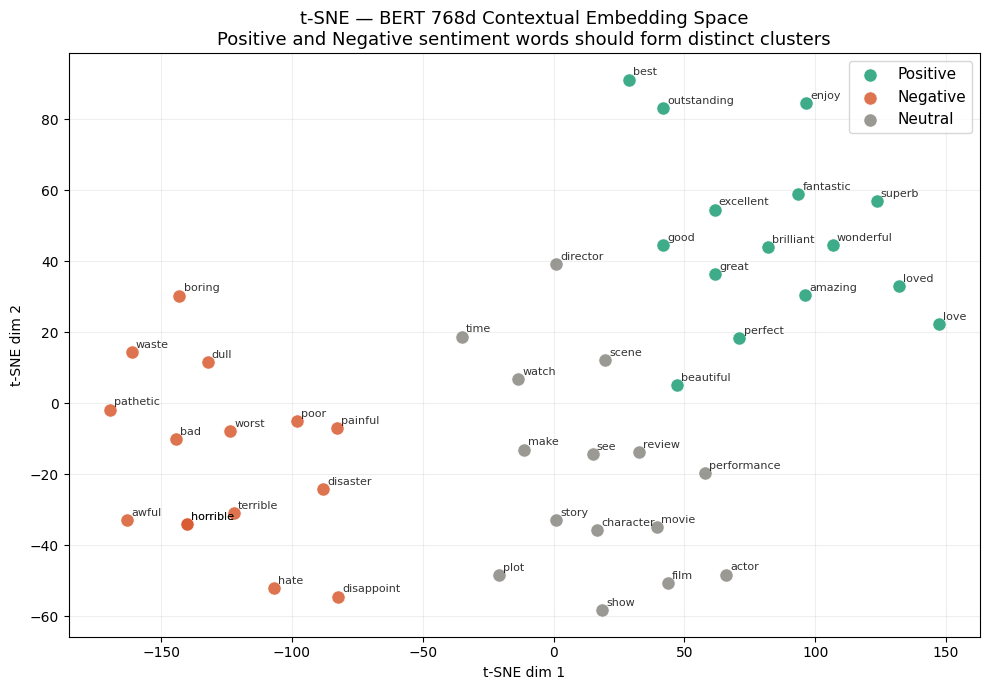

In [19]:
# ── Step X — t-SNE BERT Vector Space ─────────────────────────────
from sklearn.manifold import TSNE

sentiment_words = {
    'positive': ['good','great','excellent','amazing','brilliant',
                 'wonderful','love','best','perfect','fantastic',
                 'outstanding','superb','enjoy','beautiful','loved'],
    'negative': ['bad','terrible','awful','horrible','boring',
                 'hate','worst','poor','dull','disappoint',
                 'waste','painful','disaster','pathetic','horrible'],
    'neutral' : ['film','movie','watch','scene','story','actor',
                 'plot','time','make','show','see','character',
                 'review','performance','director']
}
color_map = {'positive':'#1D9E75', 'negative':'#D85A30', 'neutral':'#888780'}

def get_bert_word_vector(word):
    """Encode a single word through BERT and return its [CLS] embedding (768-d)."""
    encoded = tokenizer(
        word,
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=16
    )
    input_ids      = encoded['input_ids'].to(device)
    attention_mask = encoded['attention_mask'].to(device)

    model.eval()
    with torch.no_grad():
        outputs = model.bert(input_ids=input_ids, attention_mask=attention_mask)
        # [CLS] token at position 0 — summarises the full input
        cls_vec = outputs.last_hidden_state[:, 0, :].squeeze(0).cpu().numpy()
    return cls_vec

word_list, vectors, cat_list = [], [], []
for cat, words in sentiment_words.items():
    for w in words:
        word_list.append(w)
        vectors.append(get_bert_word_vector(w))
        cat_list.append(cat)

print(f'Words encoded with BERT: {len(word_list)}/{sum(len(v) for v in sentiment_words.values())}')

X_vecs = np.array(vectors)                                        # (45, 768)
tsne   = TSNE(n_components=2, perplexity=12, max_iter=1500, random_state=42)
X_2d   = tsne.fit_transform(X_vecs)

fig, ax = plt.subplots(figsize=(10, 7))
for cat, color in color_map.items():
    mask = [i for i, c in enumerate(cat_list) if c == cat]
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, s=90,
               alpha=0.85, label=cat.capitalize(),
               edgecolors='white', linewidths=0.5, zorder=3)
    for i in mask:
        ax.annotate(word_list[i], (X_2d[i, 0], X_2d[i, 1]),
                    fontsize=8, alpha=0.8,
                    xytext=(3, 3), textcoords='offset points')

ax.set_title('t-SNE — BERT 768d Contextual Embedding Space\n'
             'Positive and Negative sentiment words should form distinct clusters',
             fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.2)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
plt.tight_layout()
plt.show()

## Step 9 --- Final Summary

        FINAL SUMMARY — Transformer + BERT on IMDb
                     F1-Score Accuracy Precision Recall
Condition                                              
Clean test set         0.9115    0.911    0.9062  0.917
Char noise @ 10%       0.8970        —         —      —
Char noise @ 30%       0.8600        —         —      —
Word dropout @ 10%     0.9034        —         —      —
Word dropout @ 30%     0.8806        —         —      —
OOV injection @ 10%    0.8977        —         —      —
OOV injection @ 30%    0.8293        —         —      —


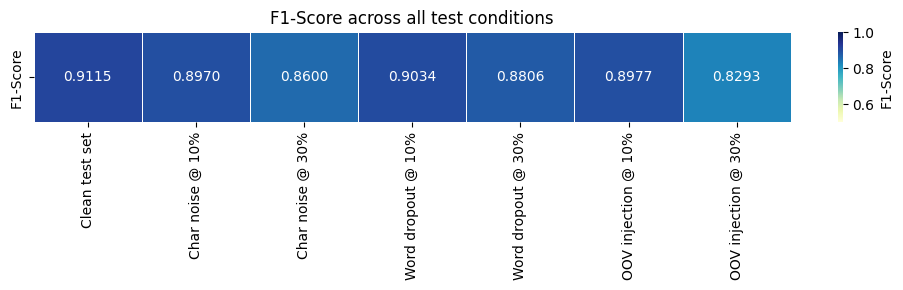


Project complete ✓
  F1-Score (primary) : 0.9115
  Accuracy           : 0.9110
  AUC-ROC            : 0.9704
  Best noise drop    : Char noise +0.0982


In [24]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score

rows = []
rows.append({
    'Condition' : 'Clean test set',
    'F1-Score'  : round(f1,  4),       # <-- primary metric first
    'Accuracy'  : round(acc, 4),
    'Precision' : round(precision_score(y_test, y_pred), 4),
    'Recall'    : round(recall_score(y_test, y_pred),    4),
})

for label, fn, _ in noise_configs:
    for lvl_idx, lvl_pct in [(2, '10%'), (4, '30%')]:
        rows.append({
            'Condition' : f'{label} @ {lvl_pct}',
            'F1-Score'  : snr_results[label][lvl_idx],   # <-- F1 values
            'Accuracy'  : '—',
            'Precision' : '—',
            'Recall'    : '—',
        })

df = pd.DataFrame(rows).set_index('Condition')

print('=' * 72)
print('        FINAL SUMMARY — Transformer + BERT on IMDb')  # <-- fixed
print('=' * 72)
print(df.to_string())
print('=' * 72)

# Heatmap on F1-Score column
fig, ax = plt.subplots(figsize=(10, 3))
numeric = df[['F1-Score']].apply(pd.to_numeric, errors='coerce').dropna()
sns.heatmap(numeric.T, annot=True, fmt='.4f', cmap='YlGnBu',
            linewidths=0.5, vmin=0.5, vmax=1.0, ax=ax,
            cbar_kws={'label': 'F1-Score'})
ax.set_title('F1-Score across all test conditions', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('\nProject complete ✓')
print(f'  F1-Score (primary) : {f1:.4f}')     # <-- F1 first
print(f'  Accuracy           : {acc:.4f}')
print(f'  AUC-ROC            : {roc_auc:.4f}')
print(f'  Best noise drop    : '
      + min(f"{label} {snr_results[label][0]-snr_results[label][-1]:+.4f}"
            for label, _, _ in noise_configs))

## Appendix: Hyperparameter Tuning Guide

The Transformer architecture is the heart of this experiment. Here are the key hyperparameters you can tune:

| Parameter | Current | Range | Effect |
|-----------|---------|-------|--------|
| `D_MODEL` | 768 | 512-1024 | Must match BERT hidden size |
| `N_HEADS` | 8 | 4-16 | More heads = more parallel attention patterns |
| `N_LAYERS` | 3 | 1-6 | More layers = deeper representations |
| `D_FF` | 1024 | 512-2048 | Feed-forward dimension |
| `DROPOUT` | 0.2 | 0.1-0.5 | Regularization |
| `LR` | 2e-5 | 1e-5-5e-5 | Learning rate for BERT fine-tuning |
| `BATCH_SIZE` | 32 | 16-64 | Memory vs speed tradeoff |
| `EPOCHS` | 3 | 2-5 | BERT converges quickly |

### Tips for better accuracy:
1. **Increase N_LAYERS**: Try 4-6 layers for deeper understanding
2. **Adjust N_HEADS**: Use 12 heads for better parallel attention
3. **Longer training**: Increase EPOCHS to 4-5 with early stopping
4. **Learning rate**: Try 1e-5 for more stable fine-tuning
5. **MAX_LEN**: Increase to 512 for longer reviews